## Block 1: Libraries Import, Well-Log Data Loading & Figure 6 Visualization

In [1]:
import sys
import os
import time
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm

sys.path.append(os.path.abspath('..'))
from igmn import IGMN

# Load real well-log data
data = sio.loadmat('../data/data4.mat')
depth = data['Depth'].flatten()
facies = data['Facies3'].flatten()
alpha, beta, rho = data['Vp'].flatten(), data['Vs'].flatten(), data['Rho'].flatten()
phi, vc, sw = data['Phi'].flatten(), data['Clay'].flatten(), data['Sw'].flatten()

# Scale velocity to m/s if necessary
if np.max(alpha) < 10:
    alpha *= 1000
    beta *= 1000

# Fit a simple rock physics model (linear regression)
X_real = np.column_stack((phi, vc, sw))
Y_real = np.column_stack((alpha, beta, rho))
rpm_model = LinearRegression().fit(X_real, Y_real)

# Monte Carlo simulation parameters
np.random.seed(42)
n_sim = {'Shale': 8000, 'Brine Sand': 3000, 'Oil Sand': 4000}
params = {
    'Shale':      {'mu': [0.18, 0.30, 0.86], 'std': [0.036, 0.202, 0.211], 'code': 2},
    'Brine Sand': {'mu': [0.24, 0.07, 0.95], 'std': [0.017, 0.060, 0.020], 'code': 3},
    'Oil Sand':   {'mu': [0.27, 0.09, 0.20], 'std': [0.018, 0.068, 0.347], 'code': 1}
}

# Generate synthetic petrophysical data using rejection sampling
petro_sim_list = []
for name, p in params.items():
    mu, cov = np.array(p['mu']), np.diag(np.array(p['std'])**2)
    n_needed = n_sim[name]
    
    valid_points = []
    while len(valid_points) < n_needed:
        pts = np.random.multivariate_normal(mu, cov, size=n_needed)
        valid = (pts[:,0]>=0) & (pts[:,0]<=0.4) & (pts[:,1]>=0) & (pts[:,1]<=0.8) & (pts[:,2]>=0) & (pts[:,2]<=1.0)
        valid_points.extend(pts[valid])
        
    final_points = np.array(valid_points[:n_needed])
    facies_col = np.full((n_needed, 1), p['code'])
    petro_sim_list.append(np.hstack((final_points, facies_col)))

petro_sim = np.vstack(petro_sim_list)
phi_sim, clay_sim, sw_sim, facies_sim = petro_sim.T

# Predict elastic properties and add 5% noise
X_sim = np.column_stack((phi_sim, clay_sim, sw_sim))
elastic_clean = rpm_model.predict(X_sim)
elastic_sim = elastic_clean + 0.05 * np.std(elastic_clean, axis=0) * np.random.randn(*elastic_clean.shape)
vp_sim, vs_sim, rho_sim = elastic_sim.T

# Final datasets
train_data = np.column_stack((facies_sim, vp_sim, vs_sim, rho_sim, phi_sim, clay_sim, sw_sim))
test_data = np.column_stack((facies, alpha, beta, rho, phi, vc, sw))

## Block 2: Rock Physics Modeling & Monte Carlo Synthetic Data Generation (Figure 9)

In [2]:
# Select 1100 random samples and sort by facies
np.random.seed(42)
idx_1100 = np.random.choice(len(train_data), 1100, replace=False)
train_data_1100 = train_data[idx_1100]
train_data_1100 = train_data_1100[np.argsort(train_data_1100[:, 0])]

# Scaler for the model WITH facies (7 columns)
scaler_facies = MinMaxScaler(feature_range=(0, 1))
train_scaled_facies = scaler_facies.fit_transform(train_data_1100)
test_scaled_facies = scaler_facies.transform(test_data)
in_idx_facies, out_idx_facies = [0, 1, 2, 3], [4, 5, 6]

# Scaler for the model WITHOUT facies (6 columns, ignore facies)
scaler_no = MinMaxScaler(feature_range=(0, 1))
train_scaled_no = scaler_no.fit_transform(train_data_1100[:, 1:])
test_scaled_no = scaler_no.transform(test_data[:, 1:])
in_idx_no, out_idx_no = [0, 1, 2], [3, 4, 5]

# Hyperparameters
tau_nov, delta, sp_min, v_min = 0.118, 0.294, 12, 18

# Train model with facies
print("Training IGMN (With Facies)")
igmn_facies = IGMN(tau_nov, delta, sp_min, v_min)
t0 = time.time()
igmn_facies.fit(train_scaled_facies)
train_time_facies = time.time() - t0
print(f"Neurons: {igmn_facies.K} Time: {train_time_facies:.4f}s\n")

# Train model without facies
print("Training IGMN (Without Facies)")
igmn_no_facies = IGMN(tau_nov, delta, sp_min, v_min)
t0 = time.time()
igmn_no_facies.fit(train_scaled_no)
train_time_no_facies = time.time() - t0
print(f"Neurons: {igmn_no_facies.K} Time: {train_time_no_facies:.4f}s")

Training IGMN (With Facies)
Neurons: 3 Time: 0.0659s

Training IGMN (Without Facies)
Neurons: 2 Time: 0.0587s


## Block 3: MinMaxScaler Normalization, IGMN Training & learned GMM Ellipsoids (Figure 10)

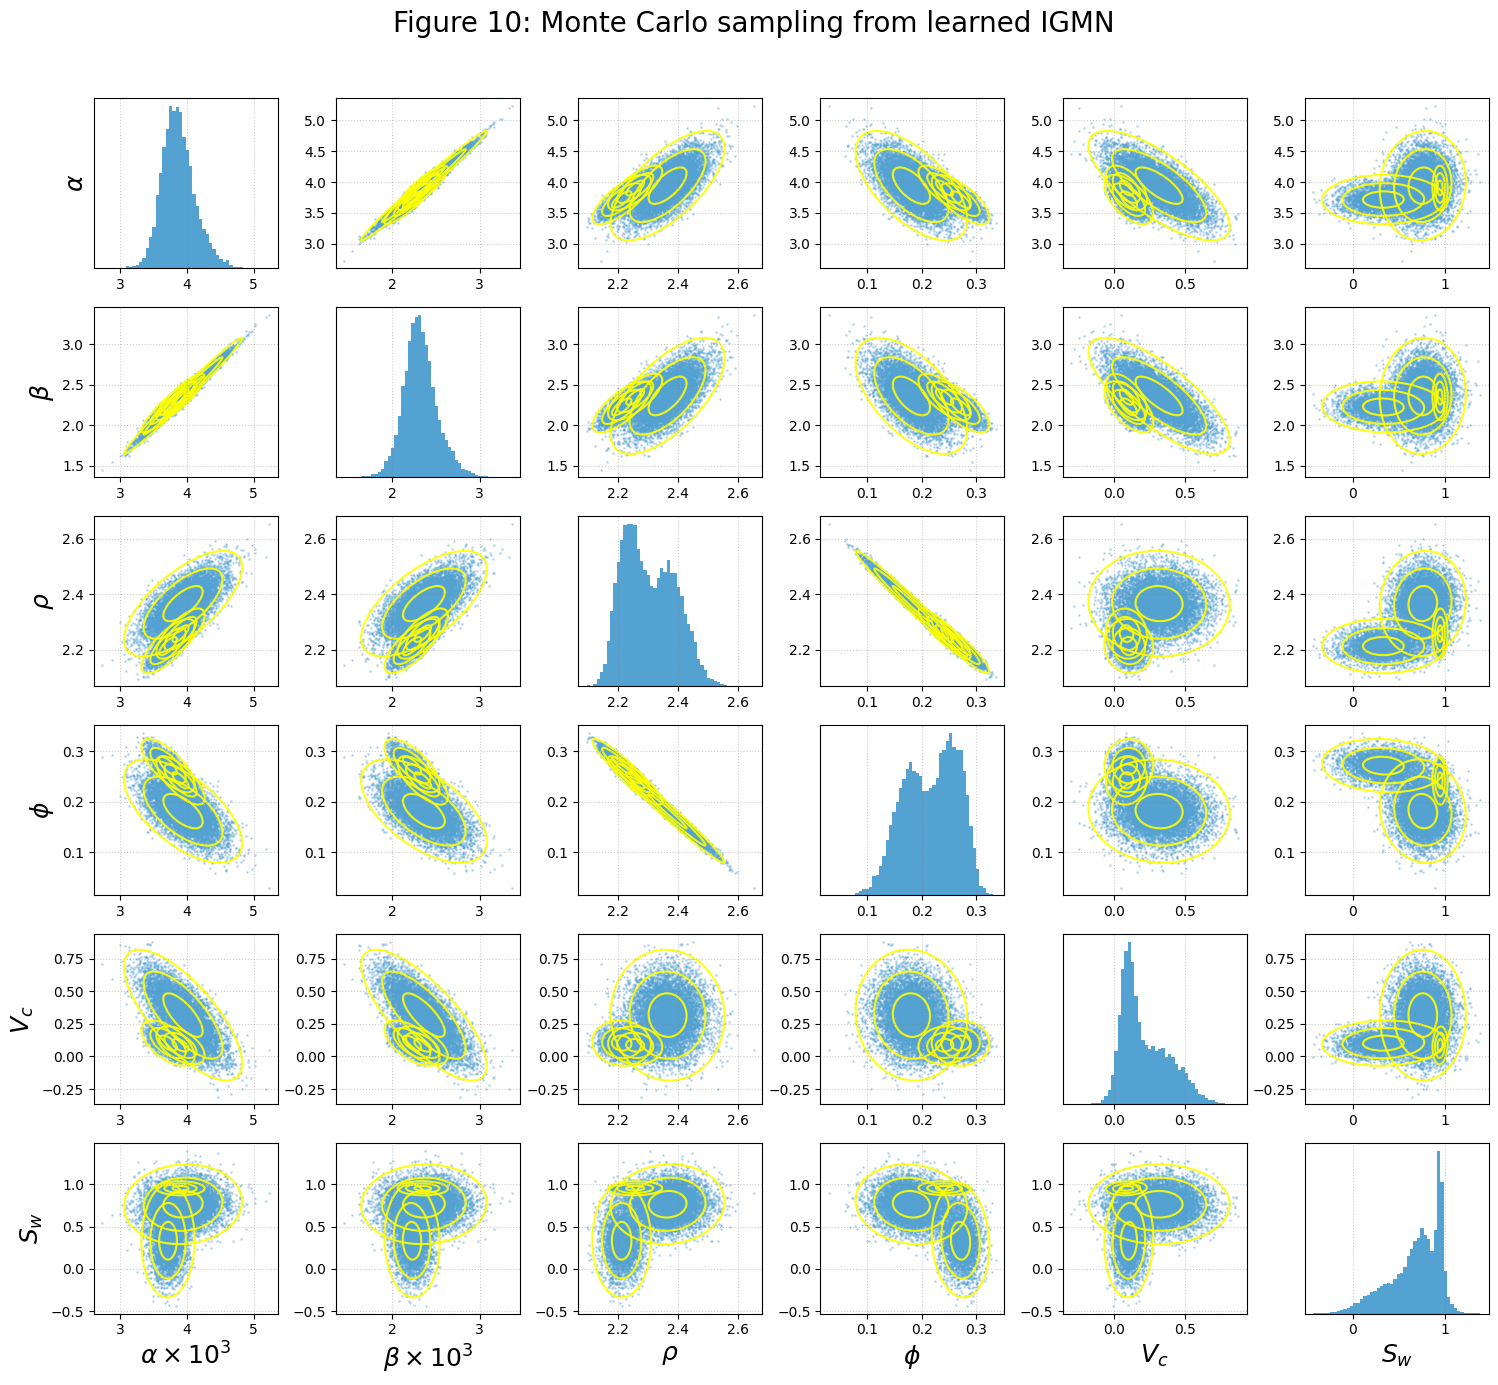

In [ ]:
# Sample 15,000 points from the trained IGMN (with facies)
sampled_sc = np.zeros((15000, 7))
for i in range(15000):
    k = np.random.choice(igmn_facies.K, p=igmn_facies.priors)
    sampled_sc[i] = np.random.multivariate_normal(igmn_facies.mu[k], igmn_facies.C[k])

sampled_phys = scaler_facies.inverse_transform(sampled_sc)
plot_data = np.copy(sampled_phys[:, 1:]) 
plot_data[:, :2] /= 1000.0  # Convert Vp, Vs to km/s

labels_y = [r'$\alpha$', r'$\beta$', r'$\rho$', r'$\phi$', r'$V_c$', r'$S_w$']
labels_x = [r'$\alpha \times 10^3$', r'$\beta \times 10^3$', r'$\rho$', r'$\phi$', r'$V_c$', r'$S_w$']

def draw_ellipses(model, ax, var_x, var_y):
    """Draws 1, 2, and 3-sigma covariance ellipses for mature components."""
    for k in range(model.K):
        if model.sp[k] < model.sp_min: 
            continue
            
        idx_x, idx_y = var_x + 1, var_y + 1 
        scale_x = scaler_facies.data_max_[idx_x] - scaler_facies.data_min_[idx_x]
        scale_y = scaler_facies.data_max_[idx_y] - scaler_facies.data_min_[idx_y]
        
        mu_x = model.mu[k][idx_x] * scale_x + scaler_facies.data_min_[idx_x]
        mu_y = model.mu[k][idx_y] * scale_y + scaler_facies.data_min_[idx_y]
        
        C_2d = model.C[k][np.ix_([idx_x, idx_y], [idx_x, idx_y])]
        S = np.diag([scale_x, scale_y])
        C_phys = S @ C_2d @ S
        
        if var_x < 2: mu_x /= 1000.0; C_phys[0,:] /= 1000.0; C_phys[:,0] /= 1000.0
        if var_y < 2: mu_y /= 1000.0; C_phys[1,:] /= 1000.0; C_phys[:,1] /= 1000.0

        eigvals, eigvecs = np.linalg.eigh(C_phys)
        order = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        
        for n_std in [1, 2, 3]:
            w, h = 2 * n_std * np.sqrt(np.maximum(eigvals, 1e-8))
            ell = Ellipse(xy=(mu_x, mu_y), width=w, height=h, angle=angle, 
                          edgecolor='yellow', facecolor='none', linewidth=1.5, alpha=0.9)
            ax.add_patch(ell)

# Plotting matrix
fig, axs = plt.subplots(6, 6, figsize=(15, 15), facecolor='white')
fig.suptitle('Figure 10: Monte Carlo sampling from learned IGMN', fontsize=20, y=0.92)

for i in range(6):
    for j in range(6):
        ax = axs[i, j]
        ax.set_facecolor('white')
        if i == j:
            ax.hist(plot_data[:, j], bins=50, color='#54a2d2', edgecolor='none', density=True)
            ax.set_yticks([]) 
        else:
            ax.scatter(plot_data[:, j], plot_data[:, i], c='#54a2d2', s=1.0, alpha=0.3)
            draw_ellipses(igmn_facies, ax, j, i)
        
        if j == 0: ax.set_ylabel(labels_y[i], fontsize=18)
        if i == 5: ax.set_xlabel(labels_x[j], fontsize=18)
        ax.grid(True, linestyle=':', color='gray', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## Block 4: Well-Log Petrophysical Inversion, Uncertainty Propagation & Figure 11 Visualization

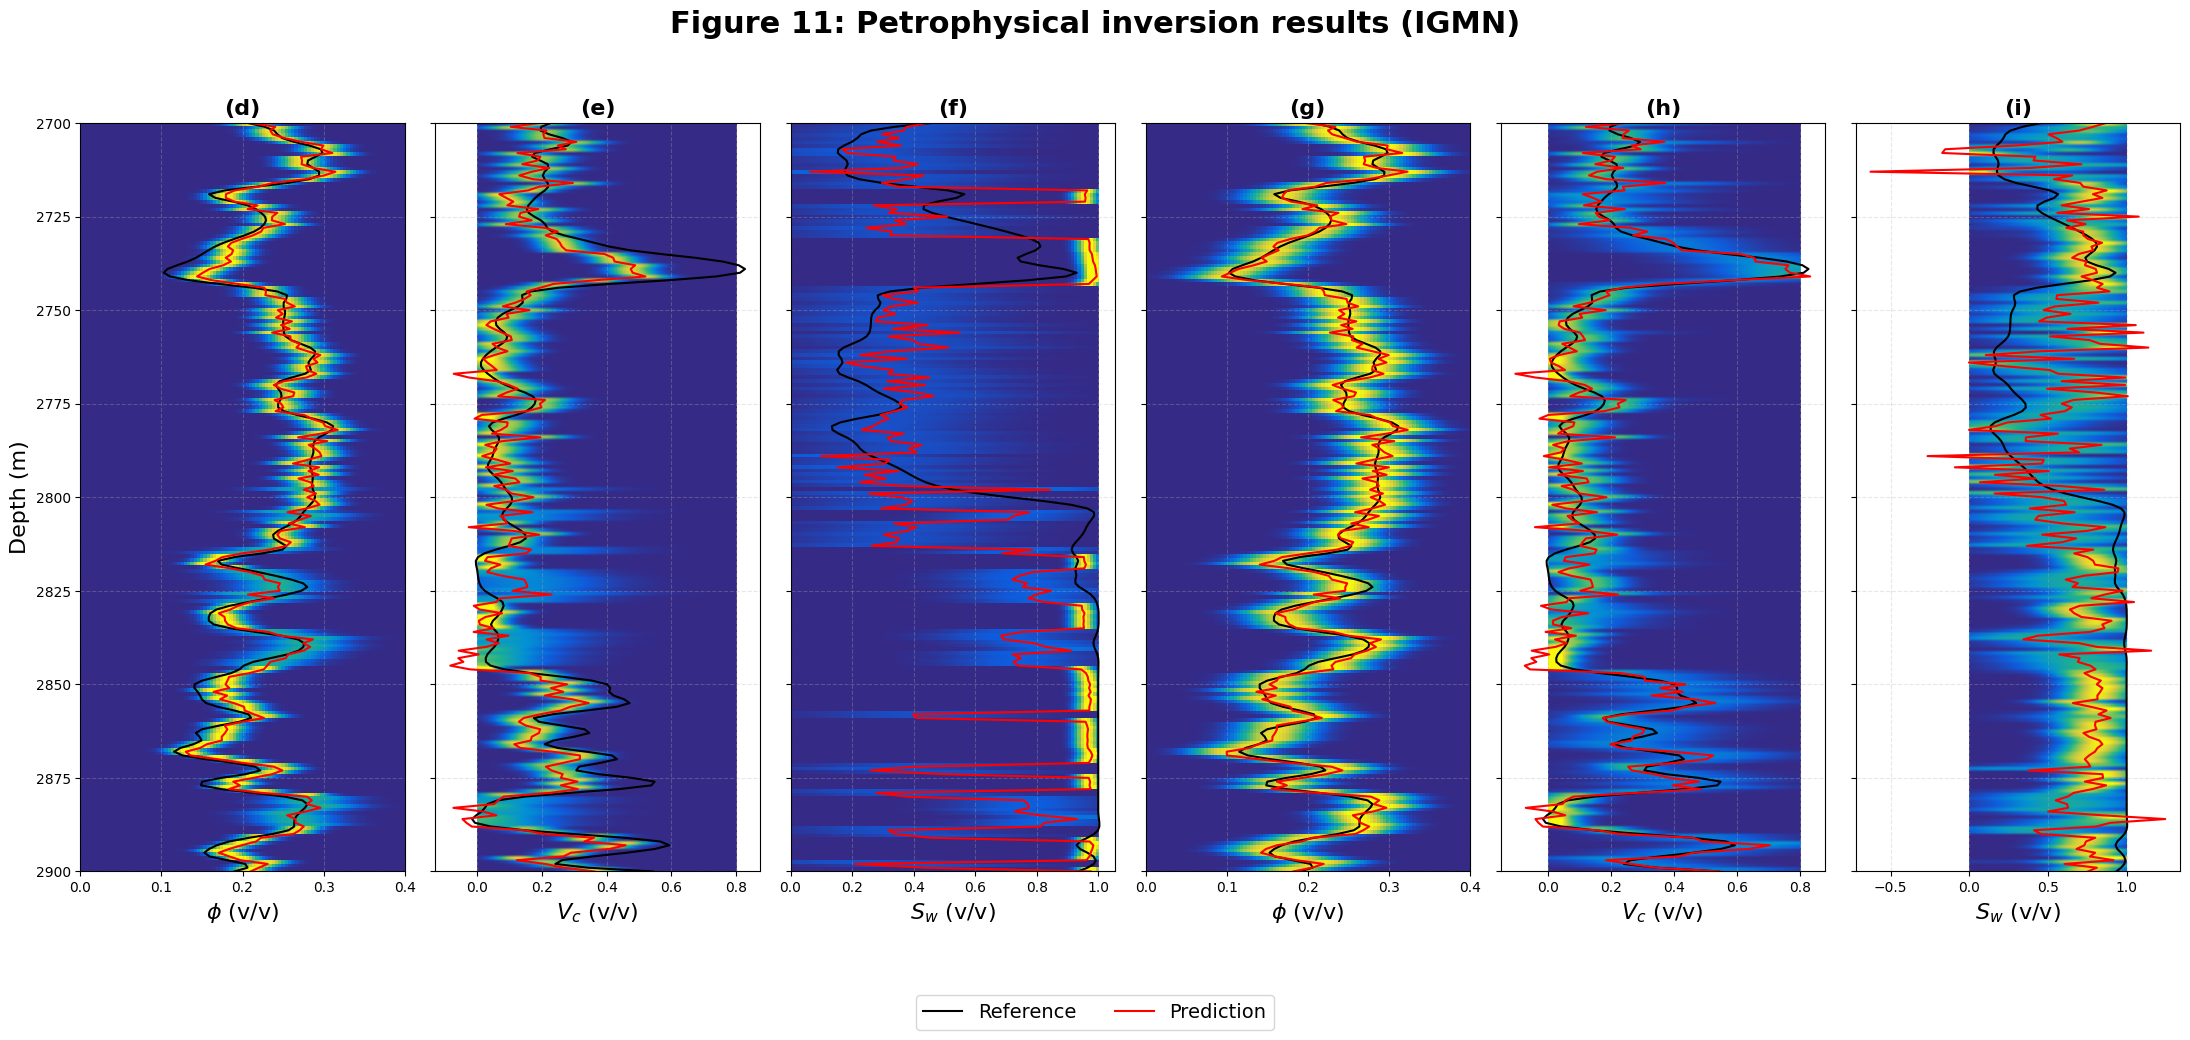

In [4]:
# Define custom Parula colormap
parula_colors = [(0.2081, 0.1663, 0.5292), (0.0592, 0.3582, 0.8606), (0.0118, 0.5721, 0.8286),
                 (0.1278, 0.6953, 0.5518), (0.4883, 0.7709, 0.3444), (0.8521, 0.8034, 0.2312),
                 (0.9763, 0.9831, 0.0538)]
parula_map = LinearSegmentedColormap.from_list('parula', parula_colors)

# Setup inputs and targets
X_test_facies = test_scaled_facies[:, in_idx_facies]
X_test_no = test_scaled_no[:, in_idx_no]
Y_true = test_data[:, 4:7]

def predict_and_denorm(model, X_test, in_idx, out_idx, scaler):
    """Predicts conditional means and denormalizes outputs."""
    preds_sc = np.array([model.predict_conditional(x, in_idx, out_idx)[0] for x in X_test])
    dummy = np.zeros((len(preds_sc), len(scaler.data_min_)))
    dummy[:, out_idx] = preds_sc 
    return scaler.inverse_transform(dummy)[:, out_idx]

Y_pred_facies = predict_and_denorm(igmn_facies, X_test_facies, in_idx_facies, out_idx_facies, scaler_facies)
Y_pred_no = predict_and_denorm(igmn_no_facies, X_test_no, in_idx_no, out_idx_no, scaler_no)

grids = {'phi': np.linspace(0, 0.4, 100), 'vc': np.linspace(0, 0.8, 100), 'sw': np.linspace(0, 1.0, 100)}

def get_pdf_bg(model, X_test, in_idx, out_idx, prop_idx, prop_key, scaler):
    """Calculates the background PDF using the marginal variance trick."""
    global_idx = out_idx[prop_idx]
    scale = scaler.data_max_[global_idx] - scaler.data_min_[global_idx]
    shift = scaler.data_min_[global_idx]
    
    grid = grids[prop_key]
    pdf_bg = np.zeros((len(grid), len(X_test)))
    
    for i, x in enumerate(X_test):
        _, weights, mus_sc, _ = model.predict_conditional(x, in_idx, out_idx)
        pdf_1d = np.zeros_like(grid)
        
        for j in range(model.K):
            if model.sp[j] < model.sp_min: continue
            var_sc = model.C[j][global_idx, global_idx] 
            
            mu_phys = mus_sc[j][prop_idx] * scale + shift
            std_phys = np.sqrt(max(var_sc, 1e-6)) * scale
            pdf_1d += weights[j] * norm.pdf(grid, loc=mu_phys, scale=std_phys)
            
        if np.sum(pdf_1d) > 0:
            pdf_1d /= np.sum(pdf_1d)
        pdf_bg[:, i] = pdf_1d
    return pdf_bg

# Plotting Figure 11
fig, axs = plt.subplots(1, 6, figsize=(22, 10), sharey=True, facecolor='white')
fig.suptitle('Figure 11: Petrophysical inversion results (IGMN)', fontsize=22, fontweight='bold', y=0.98)

configs = [
    (igmn_facies, X_test_facies, in_idx_facies, out_idx_facies, Y_pred_facies, 'phi', r'$\phi$ (v/v)', 0, scaler_facies, '(d)'),
    (igmn_facies, X_test_facies, in_idx_facies, out_idx_facies, Y_pred_facies, 'vc', r'$V_c$ (v/v)', 1, scaler_facies, '(e)'),
    (igmn_facies, X_test_facies, in_idx_facies, out_idx_facies, Y_pred_facies, 'sw', r'$S_w$ (v/v)', 2, scaler_facies, '(f)'),
    (igmn_no_facies, X_test_no, in_idx_no, out_idx_no, Y_pred_no, 'phi', r'$\phi$ (v/v)', 0, scaler_no, '(g)'),
    (igmn_no_facies, X_test_no, in_idx_no, out_idx_no, Y_pred_no, 'vc', r'$V_c$ (v/v)', 1, scaler_no, '(h)'),
    (igmn_no_facies, X_test_no, in_idx_no, out_idx_no, Y_pred_no, 'sw', r'$S_w$ (v/v)', 2, scaler_no, '(i)')
]

for ax, cfg in zip(axs, configs):
    model, X_t, in_idx, out_idx, Y_p, p_key, p_label, p_idx, scaler, letter = cfg
    ax.set_facecolor('white')
    ax.set_title(letter, fontsize=16, fontweight='bold')
    
    bg = get_pdf_bg(model, X_t, in_idx, out_idx, p_idx, p_key, scaler)
    ax.imshow(bg.T, aspect='auto', cmap=parula_map, vmin=0, vmax=np.percentile(bg, 99.5), 
              extent=[grids[p_key][0], grids[p_key][-1], depth[-1], depth[0]])
    
    ax.plot(Y_true[:, p_idx], depth, 'k', linewidth=1.5, label='Reference')
    ax.plot(Y_p[:, p_idx], depth, 'r', linewidth=1.5, label='Prediction')
    ax.set_xlabel(p_label, fontsize=16)
    if ax == axs[0]: ax.set_ylabel('Depth (m)', fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.3)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


## Block 5: Weighted RMSE Performance Evaluation & Table 3 Generation

In [5]:
def evaluate_rmse(y_true, y_pred):
    """Calculates weighted RMSE according to evaluate.m logic."""
    weights = np.array([1, 7, 16]) / 24.0
    return np.sqrt(np.mean(np.sum(((y_true - y_pred)**2) * weights, axis=1)))

rmse_fac = evaluate_rmse(Y_true, Y_pred_facies)
rmse_no = evaluate_rmse(Y_true, Y_pred_no)

print("Table 3: Comparison of models based on 1100 data points")
print("=" * 82)
print(f"| {'Model':<25} | {'Execution time (Train)':<22} | {'# of neurons':<12} | {'RMSE':<8} |")
print("-" * 82)
print(f"| {'IGMN (With Facies)':<25} | {f'{train_time_facies:.4f} s':<22} | {igmn_facies.K:<12} | {rmse_fac:<8.3f} |")
print(f"| {'IGMN (Without Facies)':<25} | {f'{train_time_no_facies:.4f} s':<22} | {igmn_no_facies.K:<12} | {rmse_no:<8.3f} |")
print("=" * 82)

Table 3: Comparison of models based on 1100 data points
| Model                     | Execution time (Train) | # of neurons | RMSE     |
----------------------------------------------------------------------------------
| IGMN (With Facies)        | 0.0659 s               | 3            | 0.218    |
| IGMN (Without Facies)     | 0.0587 s               | 2            | 0.271    |
